In [127]:
import pennylane as qp
from pennylane import numpy as np
from matplotlib import pyplot as plt
import sympy as sp

In [139]:
stocks = ["A", "B", "C", "D"]

# Binary stock variables
xA, xB, xC, xD = sp.symbols("xA xB xC xD")

# All binary variables
variables = [xA, xB, xC, xD]

# Stock decision vector
x = sp.Matrix([xA, xB, xC, xD])


#EXPECTED RETURNS
mu = sp.Matrix([0.08,   # Stock A
                0.12,   # Stock B
                0.15,   # Stock C
                0.07])    # Stock D


# COVARIANCE MATRIX

Sigma = sp.Matrix([[0.04,  0.01,  0.005, 0.002], 
                   [0.01,  0.07,  0.015, 0.003], 
                   [0.01,  0.07,  0.015, 0.003],
                   [0.002, 0.003, 0.004, 0.03]]) 


#PORTFOLIO PARAMETERS
gamma = 1.0
lmbd = 100


# 5. BUDGET * 10,000

investment = sp.Matrix([1, 2, 3, 1])
budget = 5


#MARKOWITZ OBJECTIVE
expected_return = (mu.T * x)[0]
risk = (x.T * Sigma * x)[0]

markowitz = (-expected_return + gamma * risk)

print("MARKOWITZ OBJECTIVE")
print(sp.expand(markowitz))


budget_expression = ((investment.T * x)[0] - budget)

print("MARKOWITZ BUDGET")
print(budget_expression)


# QUBO
qubo = (markowitz + lmbd * budget_expression**2)

qubo = sp.expand(qubo)

print("QUBO BEFORE BINARY REDUCTION")
print(qubo)


#BINARY REDUCTION
qubo_binary = qubo

for var in variables:

    qubo_binary = qubo_binary.subs(var**2, var)

qubo_binary = sp.expand(qubo_binary)

print("QUBO AFTER x^2 = x")
print(qubo_binary)

MARKOWITZ OBJECTIVE
0.04*xA**2 + 0.02*xA*xB + 0.015*xA*xC + 0.004*xA*xD - 0.08*xA + 0.07*xB**2 + 0.085*xB*xC + 0.006*xB*xD - 0.12*xB + 0.015*xC**2 + 0.007*xC*xD - 0.15*xC + 0.03*xD**2 - 0.07*xD
MARKOWITZ BUDGET
xA + 2*xB + 3*xC + xD - 5
QUBO BEFORE BINARY REDUCTION
100.04*xA**2 + 400.02*xA*xB + 600.015*xA*xC + 200.004*xA*xD - 1000.08*xA + 400.07*xB**2 + 1200.085*xB*xC + 400.006*xB*xD - 2000.12*xB + 900.015*xC**2 + 600.007*xC*xD - 3000.15*xC + 100.03*xD**2 - 1000.07*xD + 2500
QUBO AFTER x^2 = x
400.02*xA*xB + 600.015*xA*xC + 200.004*xA*xD - 900.04*xA + 1200.085*xB*xC + 400.006*xB*xD - 1600.05*xB + 600.007*xC*xD - 2100.135*xC - 900.04*xD + 2500


In [169]:
poly = sp.Poly(qubo_binary, *variables)

constant = 0
linear_terms = {}
quadratic_terms = {}

for powers, coefficient in poly.terms():

    degree = sum(powers)

    # -------------------------------
    # Constant
    # -------------------------------

    if degree == 0:

        constant += coefficient

    # -------------------------------
    # Linear
    # -------------------------------

    elif degree == 1:

        for i, power in enumerate(powers):

            if power == 1:

                linear_terms[i] = coefficient

    # -------------------------------
    # Quadratic
    # -------------------------------

    elif degree == 2:

        indices = [
            i
            for i, power in enumerate(powers)
            if power == 1
        ]

        if len(indices) == 2:

            quadratic_terms[
                tuple(indices)
            ] = coefficient


print("\n================================================")
print("QUBO CONSTANT")
print("================================================\n")

print(constant)


print("\n================================================")
print("QUBO LINEAR TERMS")
print("================================================\n")

for i, coefficient in linear_terms.items():

    print(
        f"{coefficient} * {variables[i]}"
    )


print("\n================================================")
print("QUBO QUADRATIC TERMS")
print("================================================\n")

for (i, j), coefficient in quadratic_terms.items():

    print(
        f"{coefficient} * "
        f"{variables[i]} * {variables[j]}"
    )


# ============================================================
# 11. QUBO -> ISING
#
# Mapping:
#
#       x_i = (1 - Z_i)/2
#
# ============================================================

Z = sp.symbols("Z0:4")

binary_to_ising = {xA: (1 - Z[0]) / 2, 
                   xB: (1 - Z[1]) / 2, 
                   xC: (1 - Z[2]) / 2, 
                   xD: (1 - Z[3]) / 2}


ising_expression = qubo_binary.subs(binary_to_ising)

ising_expression = sp.expand(ising_expression)

print("\n================================================")
print("ISING HAMILTONIAN")
print("================================================\n")

print(ising_expression)


# ============================================================
# 12. EXTRACT ISING TERMS
#
# H =
#
#       C
#       + sum_i h_i Z_i
#       + sum_ij J_ij Z_i Z_j
#
# ============================================================

ising_poly = sp.Poly(ising_expression, *Z)

ising_constant = 0
ising_linear = {}
ising_quadratic = {}

for powers, coefficient in ising_poly.terms():

    degree = sum(powers)

    # -------------------------------
    # Constant
    # -------------------------------

    if degree == 0:

        ising_constant += coefficient

    # -------------------------------
    # Z_i
    # -------------------------------

    elif degree == 1:

        for i, power in enumerate(powers):

            if power == 1:

                ising_linear[i] = coefficient

    # -------------------------------
    # Z_i Z_j
    # -------------------------------

    elif degree == 2:

        indices = [
            i
            for i, power in enumerate(powers)
            if power == 1
        ]

        if len(indices) == 2:

            ising_quadratic[
                tuple(indices)
            ] = coefficient


print("\n================================================")
print("ISING CONSTANT")
print("================================================\n")

print(ising_constant)


print("\n================================================")
print("ISING LINEAR TERMS")
print("================================================\n")

for i, coefficient in ising_linear.items():

    print(
        f"{coefficient} * Z{i}"
    )


print("\n================================================")
print("ISING QUADRATIC TERMS")
print("================================================\n")

for (i, j), coefficient in ising_quadratic.items():

    print(
        f"{coefficient} * Z{i} Z{j}"
    )


# ============================================================
# 13. CREATE PENNYLANE HAMILTONIAN
# ============================================================

coefficients = []
observables = []

# -------------------------------
# Constant term
# -------------------------------

coefficients.append(float(ising_constant))
observables.append(qp.Identity(0))


# -------------------------------
# Linear terms
# -------------------------------

for i, coefficient in ising_linear.items():

    coefficients.append(float(coefficient))
    observables.append(qp.PauliZ(i))


# -------------------------------
# Quadratic terms
# -------------------------------

for (i, j), coefficient in ising_quadratic.items():

    coefficients.append(float(coefficient))

    observables.append(
        qp.PauliZ(i) @ qp.PauliZ(j)
    )


# -------------------------------
# PennyLane Hamiltonian
# -------------------------------

H = qp.Hamiltonian(
    coefficients,
    observables
)

print(H)


print("\n================================================")
print("PENNYLANE ISING HAMILTONIAN")
print("================================================\n")

print(H)


QUBO CONSTANT

2500.00000000000

QUBO LINEAR TERMS

-900.040000000000 * xA
-1600.05000000000 * xB
-2100.13500000000 * xC
-900.040000000000 * xD

QUBO QUADRATIC TERMS

400.020000000000 * xA * xB
600.015000000000 * xA * xC
200.004000000000 * xA * xD
1200.08500000000 * xB * xC
400.006000000000 * xB * xD
600.007000000000 * xC * xD

ISING HAMILTONIAN

100.005*Z0*Z1 + 150.00375*Z0*Z2 + 50.001*Z0*Z3 + 150.01025*Z0 + 300.02125*Z1*Z2 + 100.0015*Z1*Z3 + 299.99725*Z1 + 150.00175*Z2*Z3 + 450.04075*Z2 + 150.01575*Z3 + 599.90175

ISING CONSTANT

599.901750000000

ISING LINEAR TERMS

150.010250000000 * Z0
299.997250000000 * Z1
450.040750000000 * Z2
150.015750000000 * Z3

ISING QUADRATIC TERMS

100.005000000000 * Z0 Z1
150.003750000000 * Z0 Z2
50.0010000000000 * Z0 Z3
300.021250000000 * Z1 Z2
100.001500000000 * Z1 Z3
150.001750000000 * Z2 Z3
599.9017499999998 * I(0) + 150.01025 * Z(0) + 299.99725 * Z(1) + 450.0407500000001 * Z(2) + 150.01575000000003 * Z(3) + 100.005 * (Z(0) @ Z(1)) + 150.00375 * (Z(

In [170]:
H_mix = qp.Hamiltonian([1, 1, 1, 1], 
                       [qp.PauliX(0),
                        qp.PauliX(1),
                        qp.PauliX(2),
                        qp.PauliX(3)])
H, H_mix

((
     599.9017499999998 * I(0)
   + 150.01025 * Z(0)
   + 299.99725 * Z(1)
   + 450.0407500000001 * Z(2)
   + 150.01575000000003 * Z(3)
   + 100.005 * (Z(0) @ Z(1))
   + 150.00375 * (Z(0) @ Z(2))
   + 50.001000000000005 * (Z(0) @ Z(3))
   + 300.02125 * (Z(1) @ Z(2))
   + 100.0015 * (Z(1) @ Z(3))
   + 150.00175000000002 * (Z(2) @ Z(3))
 ),
 1 * X(0) + 1 * X(1) + 1 * X(2) + 1 * X(3))

In [174]:
dev = qp.device("default.qubit")

def qaoa_layer(gamma, alpha):
    qp.qaoa.cost_layer(gamma, H/100)
    qp.qaoa.mixer_layer(alpha, H_mix)


wires = range(4)
depth = 5

def circuit(params, **kwargs):
    for w in wires:
        qp.Hadamard(wires=w)
    for i in range(depth):
        qaoa_layer(
            params[0, i],
            params[1, i]
        )

In [175]:
@qp.qnode(dev)

def cost_function(params):
    circuit(params)
    return qp.expval(H)

optimizer = qp.AdamOptimizer(stepsize=0.001)
steps = 200

In [176]:
params = qp.numpy.array([[0.1, 0.1, 0.1, 0.1, 0.1],   # gammas
                         [0.2, 0.2, 0.2, 0.2, 0.2]]    # betas
, requires_grad=True)


for i in range(steps):

    params = optimizer.step(cost_function, params)

    if i % 10 == 0:
        print(
            f"Step {i}: "
            f"Cost = {cost_function(params):.6f}"
        )

print("Final cost:", cost_function(params))
print("Final params:")
print(params)

Step 0: Cost = 1141.861072
Step 10: Cost = 1015.422968
Step 20: Cost = 894.875477
Step 30: Cost = 787.917372
Step 40: Cost = 702.610390
Step 50: Cost = 634.868346
Step 60: Cost = 570.037146
Step 70: Cost = 515.180116
Step 80: Cost = 471.120956
Step 90: Cost = 439.380397
Step 100: Cost = 418.973588
Step 110: Cost = 407.221003
Step 120: Cost = 400.871152
Step 130: Cost = 397.377209
Step 140: Cost = 395.189530
Step 150: Cost = 393.524901
Step 160: Cost = 392.039951
Step 170: Cost = 390.607913
Step 180: Cost = 389.192910
Step 190: Cost = 387.790492
Final cost: 386.54162670631445
Final params:
[[0.15364264 0.17161511 0.16374655 0.06167296 0.00513656]
 [0.13053707 0.1305322  0.26883339 0.3292836  0.3261203 ]]


In [177]:
@qp.qnode(dev)
def probability_circuit(params):
    circuit(params)
    return qp.probs(wires=wires)


probs = probability_circuit(params)

In [178]:
probs

tensor([0.00935818, 0.03649774, 0.066908  , 0.03194126, 0.0903765 ,
        0.04235256, 0.1361584 , 0.01018036, 0.03649647, 0.09251393,
        0.03194178, 0.25035422, 0.04234889, 0.10718305, 0.0101822 ,
        0.00520646], requires_grad=True)

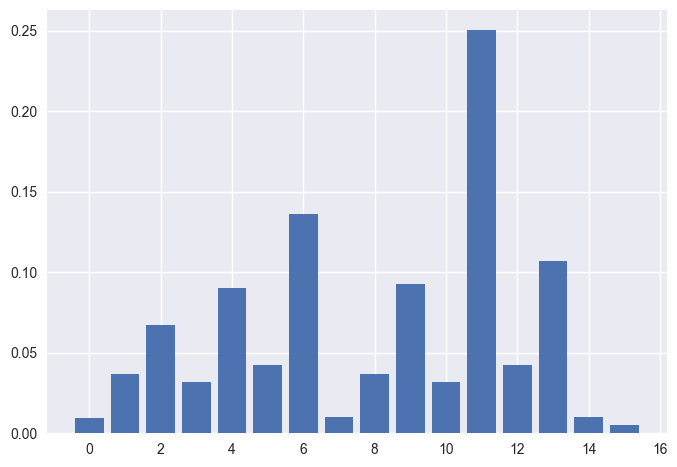

In [179]:
plt.style.use("seaborn-v0_8")
plt.bar(range(2 ** len(wires)), probs)
plt.show()

In [167]:
import itertools

for bits in itertools.product([0, 1], repeat=4):

    energy = 0.0

    for coeff, op in zip(H.coeffs, H.ops):

        value = float(coeff)

        # Get the wires on which this operator acts
        for wire in op.wires:

            if bits[wire] == 0:
                z = 1
            else:
                z = -1

            value *= z

        energy += value

    print(bits, energy)

(0, 0, 0, 0) 1900.0982500000005
(0, 0, 0, 1) 1000.0582500000002
(0, 0, 1, 0) -200.03675000000007
(0, 0, 1, 1) -500.0697500000001
(0, 1, 0, 0) 300.04825000000017
(0, 1, 0, 1) -199.9857499999999
(0, 1, 1, 0) -600.00175
(0, 1, 1, 1) -500.0287500000002
(1, 0, 0, 0) 1000.0582500000002
(1, 0, 0, 1) 300.0222500000001
(1, 0, 1, 0) -500.0617500000002
(1, 0, 1, 1) -600.0907500000002
(1, 1, 0, 0) -199.97174999999993
(1, 1, 0, 1) -500.00175
(1, 1, 1, 0) -500.0067500000001
(1, 1, 1, 1) -200.02975000000038


In [166]:
import itertools

for bits in itertools.product([0, 1], repeat=4):

    xa, xb, xc, xd = bits

    energy = (
        -expected_return.subs({
            xA: xa,
            xB: xb,
            xC: xc,
            xD: xd
        })
        + gamma * risk.subs({
            xA: xa,
            xB: xb,
            xC: xc,
            xD: xd
        })
        + lmbd * (
            xa + 2*xb + 3*xc + xd - 5
        )**2
    )

    print(bits, float(energy))

(0, 0, 0, 0) 2500.0
(0, 0, 0, 1) 1599.96
(0, 0, 1, 0) 399.865
(0, 0, 1, 1) 99.832
(0, 1, 0, 0) 899.95
(0, 1, 0, 1) 399.916
(0, 1, 1, 0) -0.1
(0, 1, 1, 1) 99.873
(1, 0, 0, 0) 1599.96
(1, 0, 0, 1) 899.924
(1, 0, 1, 0) 99.84
(1, 0, 1, 1) -0.18899999999999997
(1, 1, 0, 0) 399.93
(1, 1, 0, 1) 99.9
(1, 1, 1, 0) 99.895
(1, 1, 1, 1) 399.872
